# Análise Exploratória de Dados: Wine Quality (UCI)

Este notebook faz a análise exploratória do dataset **Wine Quality**, do UCI Machine Learning Repository. Ele foi escrito para ser lido do início ao fim — cada conceito estatístico novo é explicado no momento em que aparece, então não é preciso ter estudado estatística antes.

**Fonte dos dados:** [UCI Machine Learning Repository — Wine Quality](https://archive.ics.uci.edu/dataset/186/wine+quality)


## Antes de começar: o que é EDA?

EDA significa **Análise Exploratória de Dados** (em inglês, *Exploratory Data Analysis*). É a etapa em que olhamos os dados com calma — antes de treinar qualquer modelo — para entender como eles se comportam: quais valores são comuns, quais são raros, quais variáveis parecem se relacionar entre si e onde há problemas (dados faltando, valores estranhos, escalas muito diferentes).

Pular essa etapa é como um médico pedir exames antes de sequer examinar o paciente: às vezes funciona, mas o diagnóstico fica mais raso, e erros óbvios passam despercebidos. Um modelo treinado sem EDA pode aprender padrões que não existem de verdade, ou ignorar problemas nos dados que comprometem qualquer resultado.

Neste notebook você vai aprender a ler a distribuição de uma variável, identificar valores fora do padrão (outliers), medir se duas variáveis andam juntas (correlação) e comparar grupos diferentes dentro dos mesmos dados (aqui, vinho tinto vs. branco). No fim, resumimos o que os dados revelam sobre o que faz um vinho ser bem avaliado.

## Mini-glossário

Termos que vão aparecer ao longo do notebook, para consulta rápida — cada um também é apresentado com calma na primeira vez que surge no texto.

- **Variável-alvo:** a coluna que queremos entender ou prever. Aqui, `quality`, a nota do vinho.
- **Feature:** cada uma das colunas usadas para explicar a variável-alvo — no nosso caso, as propriedades químicas do vinho.
- **Mediana:** o valor que fica bem no meio dos dados quando eles são colocados em ordem — metade fica abaixo, metade acima. Ao contrário da média, não é puxada por valores extremos.
- **Quartil / IQR:** os quartis dividem os dados ordenados em quatro partes iguais. O IQR (*Interquartile Range*, intervalo interquartil) é a distância entre o primeiro quartil (25% dos dados abaixo) e o terceiro (75% abaixo) — mostra onde está a "metade do meio" dos dados.
- **Distribuição assimétrica (skew):** quando os valores não se espalham de forma equilibrada dos dois lados da média — há uma "cauda" mais longa de um lado.
- **Outlier:** um valor bem distante da maioria dos outros. Não é necessariamente um erro — pode ser um caso real e incomum.
- **Correlação de Pearson:** uma medida de o quanto duas variáveis crescem ou diminuem juntas, numa escala de -1 a 1.
- **Desbalanceamento de classes:** quando algumas categorias aparecem muito mais que outras nos dados — o que pode enganar um modelo treinado sobre eles.


## 1. Setup e carregamento dos dados

Começamos importando as bibliotecas que vamos usar (pandas para organizar os dados em tabelas, matplotlib e seaborn para os gráficos) e carregando o `jlp.mplstyle`, um arquivo de estilo que define a paleta de cores usada em todos os gráficos deste notebook.

Em seguida, baixamos os dois arquivos do dataset — um com vinhos tintos, outro com brancos — diretamente do site da UCI. Se você já rodou esta célula antes, ela não baixa de novo: reaproveita a cópia salva em `../data/`.

In [1]:
import os
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# aplica a paleta de cores customizada (fundo, grade e cores de linha/barra) a todos os gráficos
plt.style.use('../jlp.mplstyle')

PALETTE = ['#2C4A5E', '#B08D3C', '#6B5D4F', '#7A9A8B', '#9C6B3C', '#4A6B7C']
sns.set_palette(PALETTE)

%matplotlib inline

In [2]:
DATA_DIR = '../data'
os.makedirs(DATA_DIR, exist_ok=True)

BASE_URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality'
for fname in ['winequality-red.csv', 'winequality-white.csv']:
    path = os.path.join(DATA_DIR, fname)
    if not os.path.exists(path):
        # baixa o arquivo só se ele ainda não existir localmente
        print(f'Baixando {fname}...')
        urllib.request.urlretrieve(f'{BASE_URL}/{fname}', path)
    else:
        print(f'{fname} já existe em {DATA_DIR}/')

winequality-red.csv já existe em ../data/
winequality-white.csv já existe em ../data/


Os arquivos usam ponto e vírgula (`;`) como separador de colunas, não vírgula — é assim que a UCI disponibiliza esse dataset. Vamos carregar tinto e branco separadamente, criar uma coluna `tipo` para não perder essa informação, e depois juntar tudo num único DataFrame (a tabela de dados do pandas). Isso permite tanto olhar o conjunto todo quanto comparar os dois tipos de vinho mais adiante.

In [3]:
red = pd.read_csv(os.path.join(DATA_DIR, 'winequality-red.csv'), sep=';')
white = pd.read_csv(os.path.join(DATA_DIR, 'winequality-white.csv'), sep=';')

# marca a origem de cada linha antes de juntar os dois arquivos num só DataFrame
red['tipo'] = 'tinto'
white['tipo'] = 'branco'

df = pd.concat([red, white], ignore_index=True)
df.shape

(6497, 13)

Antes de qualquer gráfico, vale fazer uma checagem básica: quantas linhas e colunas temos, que tipo de dado cada coluna guarda, como são as primeiras linhas e se falta algum valor. São perguntas simples, mas é aqui que muitos problemas de dados costumam aparecer.

In [4]:
df.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
tipo                     object
dtype: object

In [5]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,tipo
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,tinto
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,tinto
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,tinto
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,tinto
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,tinto


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  tipo                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


**O que levamos daqui:** o dataset combinado tem 6.497 vinhos (1.599 tintos e 4.898 brancos) e 12 colunas numéricas, além da coluna `tipo` que criamos. O resultado de `df.info()` mostra 6.497 valores não nulos em cada coluna — ou seja, não falta nenhum dado. Isso é incomum: na prática, a maioria dos datasets reais tem valores faltando, o que exigiria decisões de limpeza (preencher? descartar?) antes de seguir. Aqui podemos pular direto para a exploração.

## 2. Contexto do domínio: o que significam essas variáveis?

Antes de olhar gráficos, vale entender o que cada coluna representa fisicamente — sem isso, um número como "acidez volátil de 0,53" não diz nada. Todas as variáveis abaixo, exceto `quality` e `tipo`, são medidas químicas feitas em laboratório:

- **fixed acidity (acidez fixa):** ácidos que não evaporam facilmente (como o tartárico) — dão a sensação de "frescor" do vinho.
- **volatile acidity (acidez volátil):** ácidos que evaporam, principalmente o acético. Em excesso, é o que dá gosto e cheiro de vinagre — considerado um defeito.
- **citric acid (ácido cítrico):** contribui para frescor e sabor; presente em pequenas quantidades.
- **residual sugar (açúcar residual):** açúcar que sobra depois da fermentação. Vinhos secos têm pouco; vinhos de sobremesa, muito.
- **chlorides (cloretos):** relacionados ao teor de sal do vinho.
- **free sulfur dioxide (SO2 livre):** a parte do dióxido de enxofre que ainda está ativa, protegendo o vinho contra oxidação e bactérias.
- **total sulfur dioxide (SO2 total):** soma do SO2 livre com o que já reagiu com outras substâncias do vinho.
- **density (densidade):** massa por volume, próxima da densidade da água — varia principalmente com o teor de açúcar e álcool.
- **pH:** mede acidez numa escala onde valores menores indicam mais ácido. Vinhos costumam ficar entre 2,7 e 4,0.
- **sulphates (sulfatos):** aditivo que também age como antioxidante e antimicrobiano.
- **alcohol (teor alcoólico):** percentual de álcool por volume.
- **quality (qualidade):** nota de 0 a 10 dada por avaliadores humanos — na prática, neste dataset, os valores vão de 3 a 9. É a nossa variável-alvo.
- **tipo:** coluna que criamos para marcar se o vinho é tinto ou branco.

Vale guardar em especial `volatile acidity` (associada a um defeito sensorial) e `alcohol` (que veremos ser a variável mais ligada à nota) — elas vão aparecer bastante daqui para frente.

## 3. Visão geral estatística

`df.describe()` calcula, para cada coluna numérica, um resumo estatístico: quantos valores existem, a média, o desvio padrão (quanto os valores costumam se afastar da média) e os quartis — os pontos que dividem os dados ordenados em quatro partes iguais (25%, 50%, 75% dos dados abaixo desse valor). O quartil de 50% é a mediana: o valor bem no meio, que costuma representar melhor o "caso típico" do que a média quando há valores extremos puxando para um lado.

Este é o primeiro contato com a escala de cada variável — e já dá para perceber diferenças grandes entre elas.

In [7]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


**O que levamos daqui:** as escalas são bem diferentes entre si. `free sulfur dioxide` chega a 289 (a unidade é mg/L), enquanto `density` fica sempre perto de 1,0 (entre 0,987 e 1,039) e `chlorides` fica na casa dos centésimos (média de 0,056). Para a exploração que estamos fazendo isso não é um problema — mas se o próximo passo for treinar um modelo sensível a escala (regressão logística, KNN, redes neurais), essas diferenças de grandeza vão exigir normalização: sem isso, o modelo pode dar peso desproporcional às variáveis com números maiores, mesmo que elas não sejam mais importantes.

A variável-alvo `quality` tem média 5,82 e mediana 6 — bem próximas, o que já sugere uma distribuição relativamente simétrica —, com desvio padrão de apenas 0,87, mesmo o intervalo teórico da nota indo de 0 a 10 (e o observado, de 3 a 9). Ou seja, as notas estão bem concentradas perto de 5 e 6. Confirmamos isso no próximo gráfico.

## 4. Distribuição da variável-alvo (`quality`)

`quality` é a nota que queremos entender — chamamos esse tipo de coluna de **variável-alvo**, porque é o que um eventual modelo tentaria prever a partir das outras (as *features*). Antes de relacioná-la com qualquer variável química, vale entender sua própria distribuição: quais notas são comuns, quais são raras — e se isso muda entre tinto e branco.

O gráfico abaixo é um gráfico de barras (*countplot*): cada barra conta quantos vinhos receberam aquela nota, separada por cor conforme o tipo.

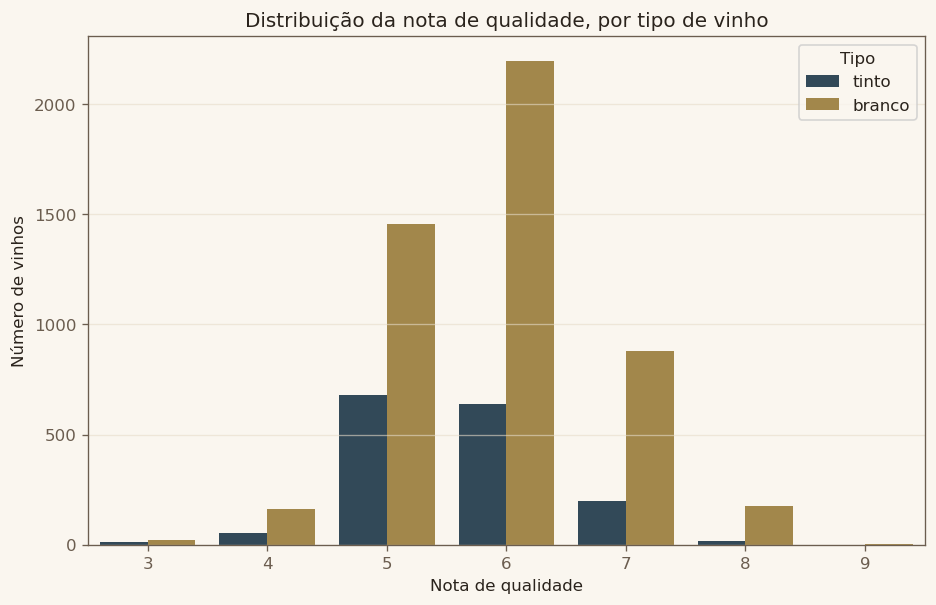

In [8]:
fig, ax = plt.subplots(figsize=(9, 5.5))

sns.countplot(data=df, x='quality', hue='tipo', palette={'tinto': PALETTE[0], 'branco': PALETTE[1]}, ax=ax)

ax.set_title('Distribuição da nota de qualidade, por tipo de vinho')
ax.set_xlabel('Nota de qualidade')
ax.set_ylabel('Número de vinhos')
ax.legend(title='Tipo')

plt.savefig('../images/distribuicao-qualidade.png')
plt.show()

In [9]:
df['quality'].value_counts().sort_index()

quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64

In [10]:
df['tipo'].value_counts()

tipo
branco    4898
tinto     1599
Name: count, dtype: int64

**O que levamos daqui:** as notas se concentram fortemente em 5, 6 e 7 — juntas, essas três notas somam 6.053 dos 6.497 vinhos, mais de 93% do dataset. Notas extremas são raras: apenas 30 vinhos com nota 3 e só 5 com nota 9.

Isso configura o que chamamos de **desbalanceamento de classes**: quando uma ou poucas categorias dominam os dados. É um problema real para modelagem — um modelo que sempre "chuta" nota 5 ou 6 já acerta boa parte dos casos, sem ter aprendido nada de útil sobre o que diferencia um vinho excelente de um mediano. Métricas simples de acerto (*accuracy*) enganam nesse cenário; é preciso olhar como o modelo se sai especificamente nas classes raras.

O dataset também é desbalanceado entre tipos: há 4.898 vinhos brancos contra 1.599 tintos — o branco tem cerca de três vezes mais registros.

## 5. Distribuições das features

Agora olhamos a forma da distribuição de cada propriedade química, uma a uma. O gráfico usado aqui é um **histograma com KDE**:

- As barras são o histograma: elas contam quantos vinhos caem em cada faixa de valor (por exemplo, quantos têm `alcohol` entre 10 e 10,5). Barras mais altas significam mais vinhos naquela faixa.
- A linha suave por cima é o **KDE** (*Kernel Density Estimate*, estimativa de densidade): uma versão "alisada" do histograma, que ajuda a enxergar o formato geral da distribuição sem depender de como as barras foram divididas.

Vale prestar atenção a três formatos: distribuições **simétricas** (parecidas dos dois lados, como um sino), distribuições **assimétricas** (com uma cauda mais longa de um lado) e distribuições **bimodais** (com dois "picos" separados, sugerindo que há dois grupos diferentes misturados nos dados).

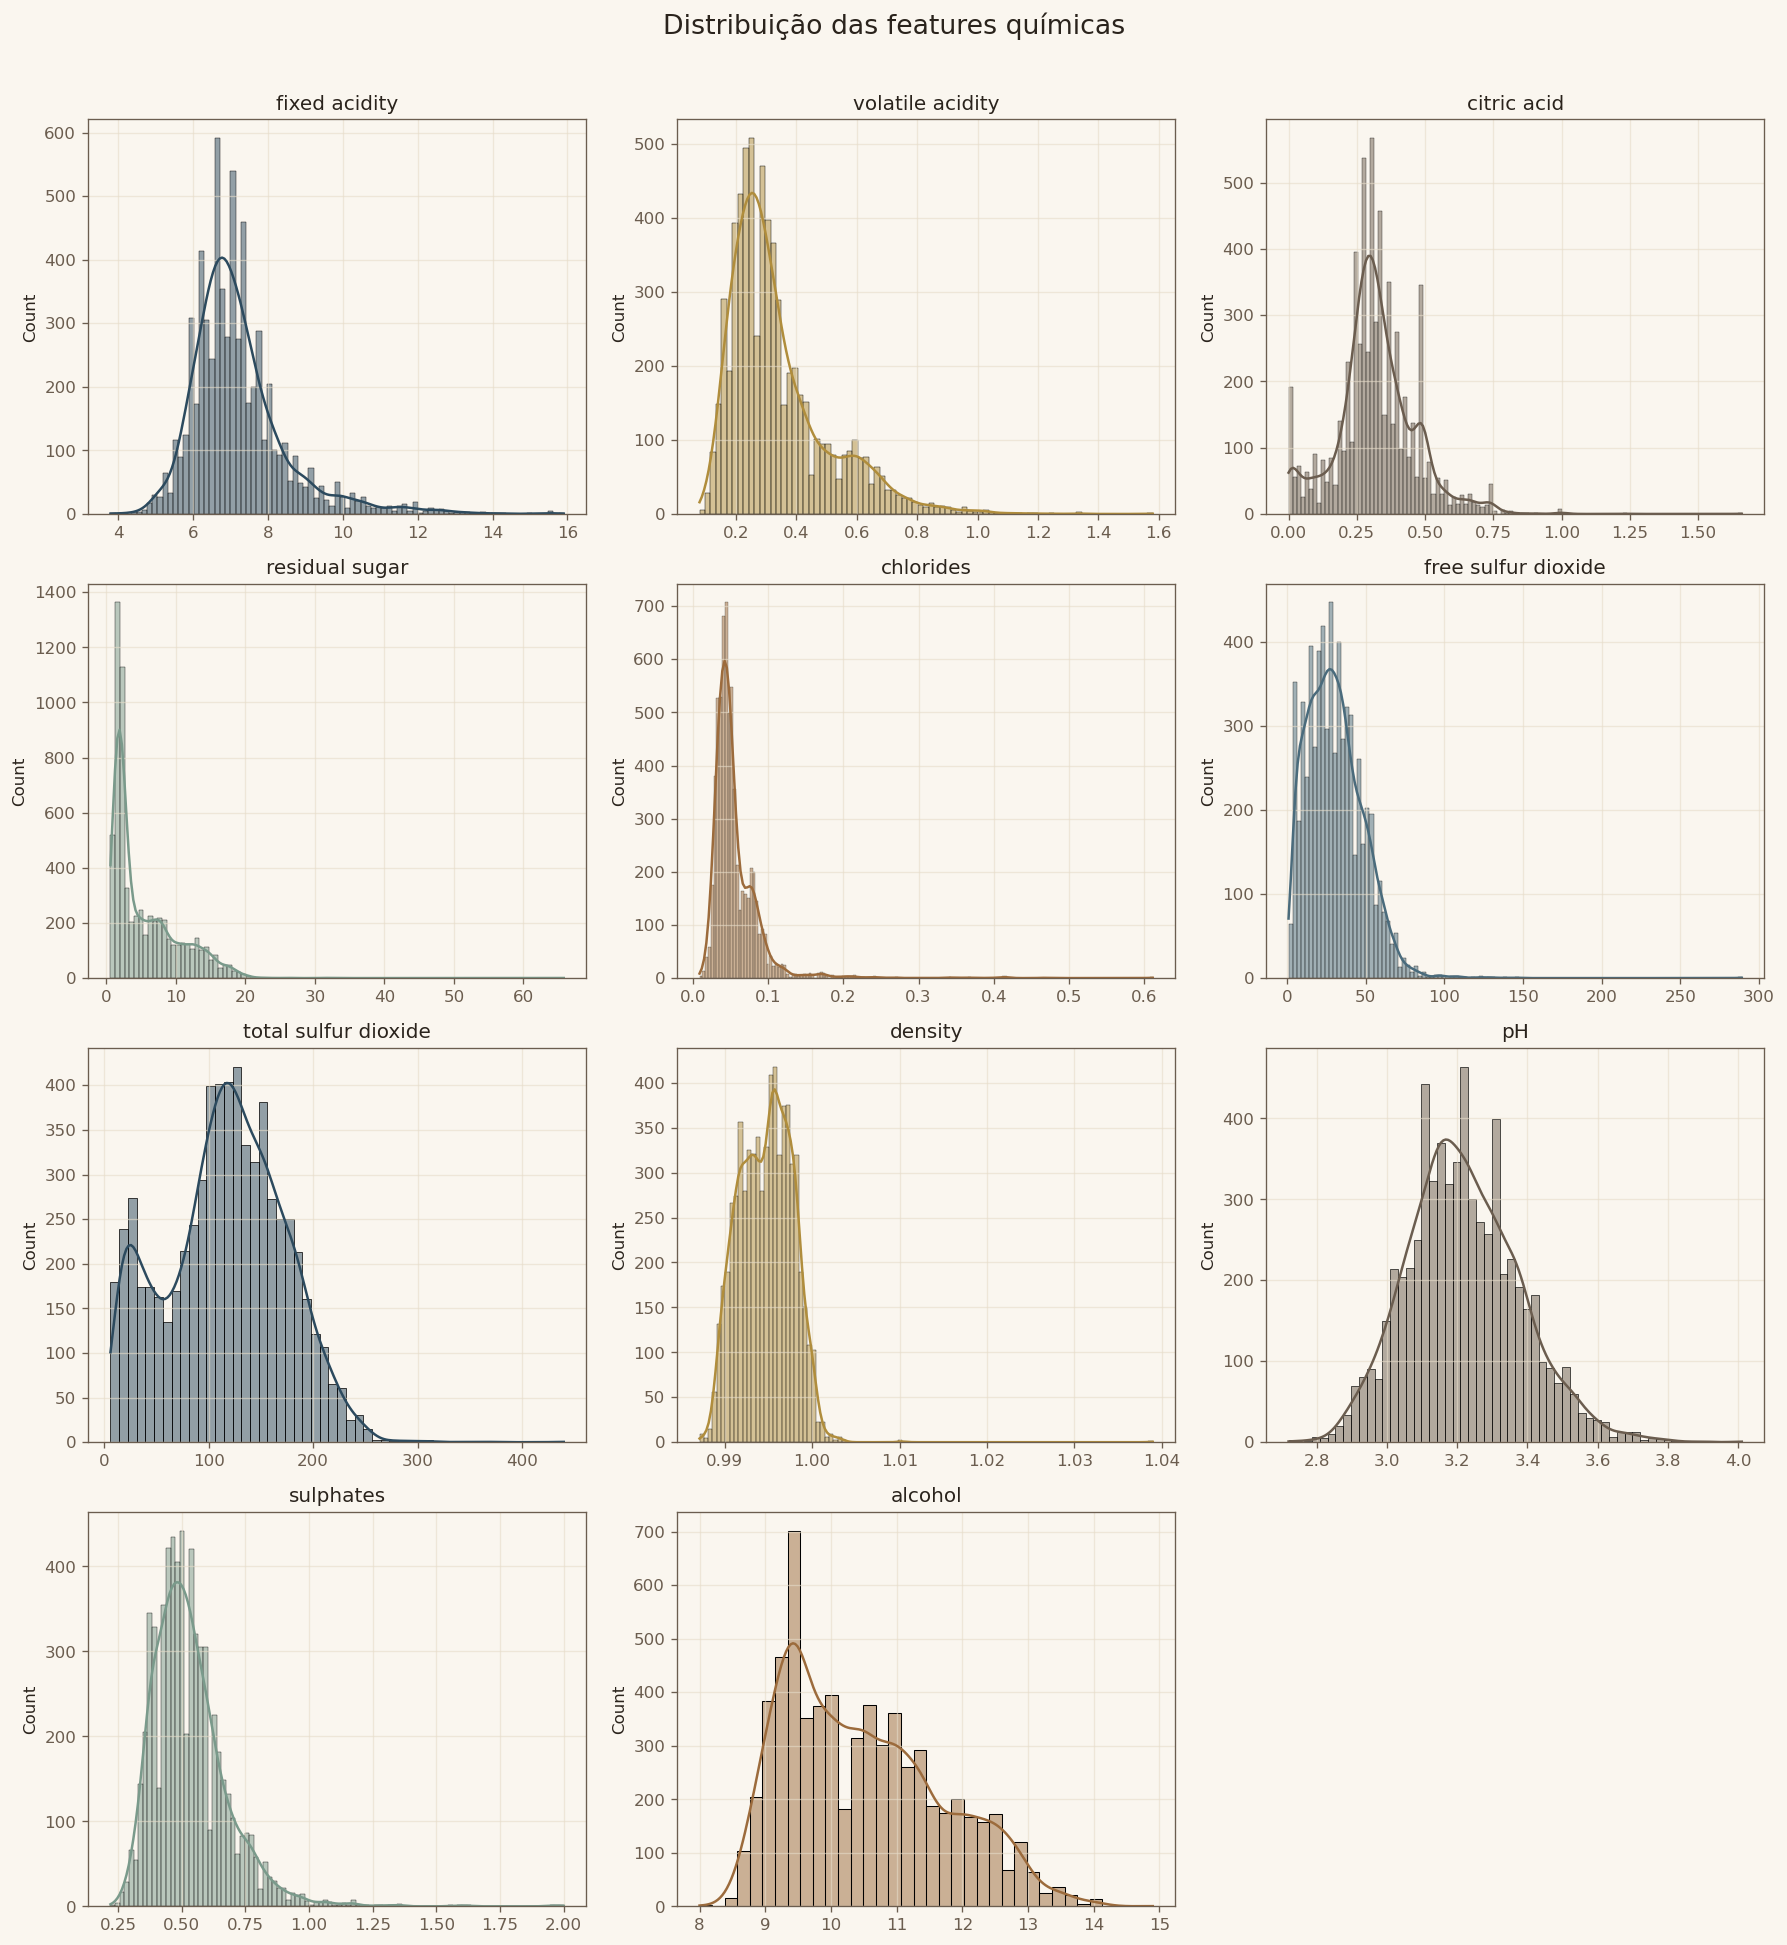

In [11]:
features = [c for c in df.columns if c not in ('quality', 'tipo')]

fig, axes = plt.subplots(4, 3, figsize=(15, 16))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(df[col], kde=True, ax=axes[i], color=PALETTE[i % len(PALETTE)])
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for ax in axes[len(features):]:
    ax.axis('off')

fig.suptitle('Distribuição das features químicas', fontsize=16, y=1.01)
fig.tight_layout()

plt.savefig('../images/histogramas-features.png')
plt.show()

In [12]:
# mede a assimetria (skew) de cada feature: quanto mais longe de zero, mais puxada para um lado
df[features].skew().sort_values(ascending=False)

chlorides               5.399828
sulphates               1.797270
fixed acidity           1.723290
volatile acidity        1.495097
residual sugar          1.435404
free sulfur dioxide     1.220066
alcohol                 0.565718
density                 0.503602
citric acid             0.471731
pH                      0.386839
total sulfur dioxide   -0.001177
dtype: float64

**O que levamos daqui:** `pH` é a variável que mais se aproxima de uma distribuição simétrica (skew de apenas 0,39, o segundo mais baixo do grupo) — faz sentido, já que pH tende a variar de forma mais controlada entre vinhos.

Já `chlorides` (skew de 5,40), `sulphates` (1,80), `fixed acidity` (1,72), `volatile acidity` (1,50) e `residual sugar` (1,44) têm cauda longa à direita: a maioria dos vinhos tem valores baixos, mas um grupo menor tem valores bem mais altos, puxando a distribuição para o lado. Quanto mais distante de zero o valor do skew, mais forte é essa assimetria.

`total sulfur dioxide` chama atenção por parecer ter dois picos no histograma — uma **distribuição bimodal**. Isso não é coincidência: é o efeito de estarmos misturando tinto e branco num único gráfico, e os dois têm níveis de SO2 bem diferentes, como vamos confirmar na seção 9.

Essas caudas longas já são um indício forte de outliers, que investigamos a seguir.

## 6. Outliers

Um **outlier** é um valor bem distante da maioria dos outros — não necessariamente um erro, apenas um caso incomum. O gráfico ideal para encontrá-los é o **boxplot** (gráfico de caixa):

- A **caixa** cobre a metade do meio dos dados (do primeiro ao terceiro quartil — os mesmos quartis de `describe()`). É o chamado IQR.
- A **linha dentro da caixa** é a mediana.
- Os **"bigodes"** (as linhas que saem da caixa) se estendem até o último valor que ainda é considerado "normal" pela convenção do boxplot.
- Os **pontos soltos** além dos bigodes são os candidatos a outlier.

Olhamos aqui as mesmas 11 features químicas, todas na mesma grade, para comparar a dispersão relativa entre elas.

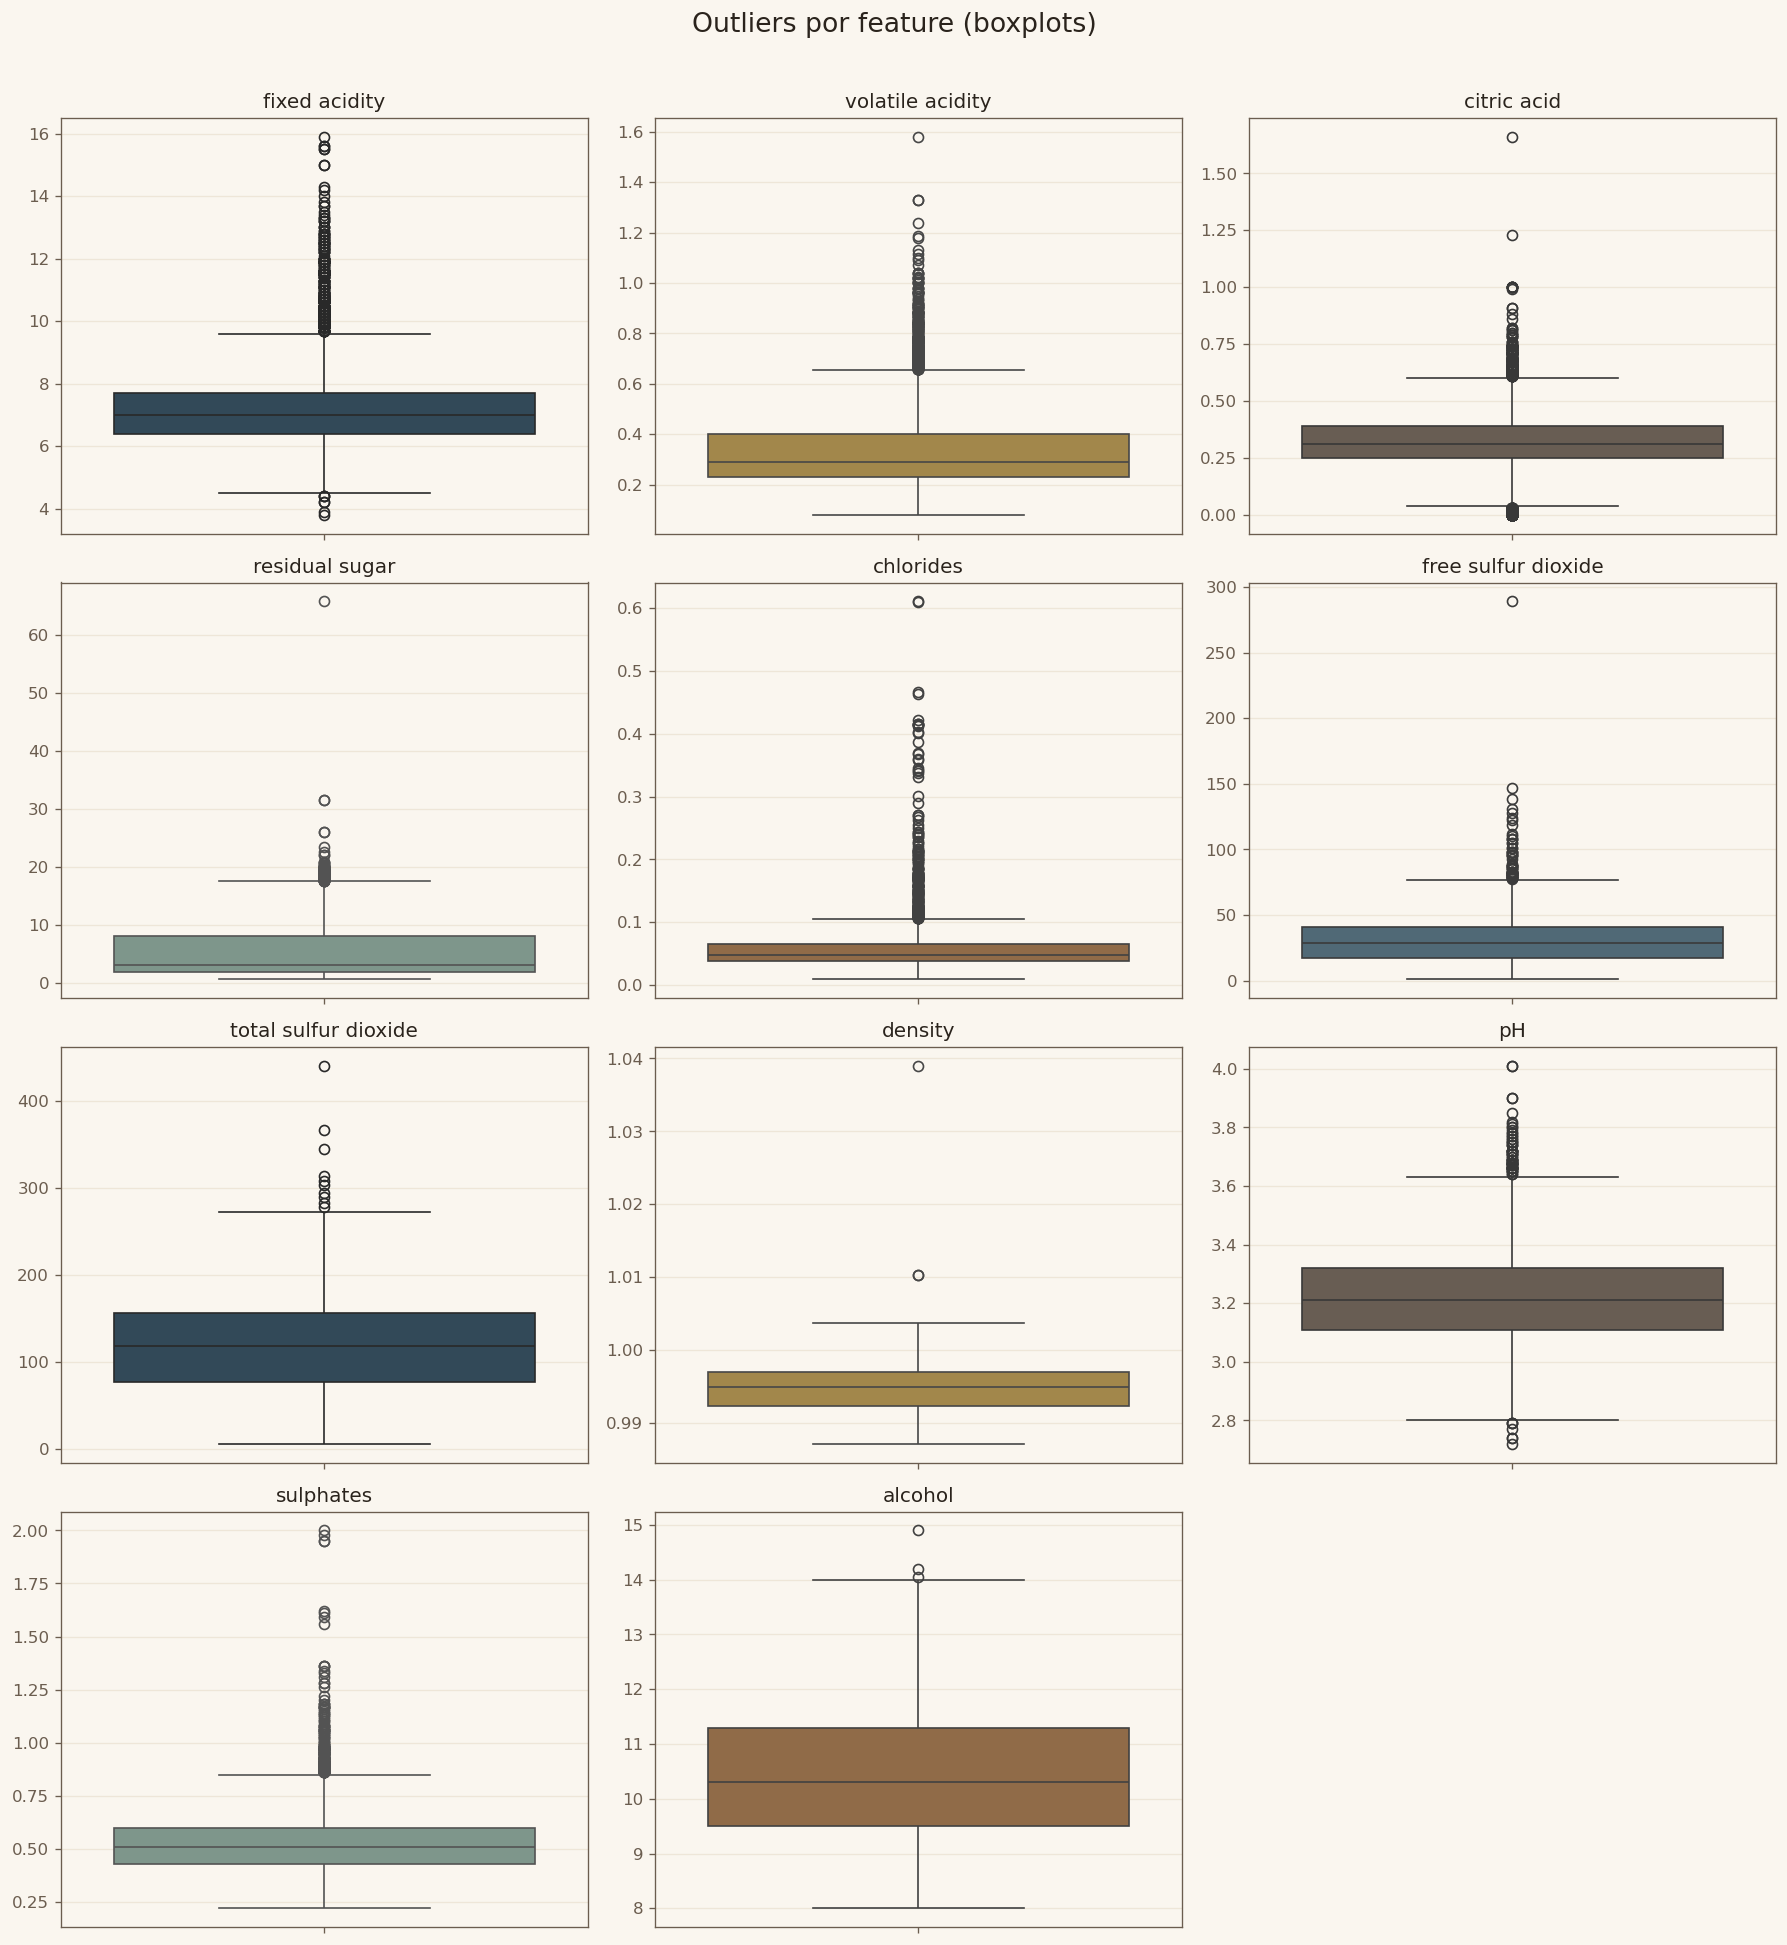

In [13]:
fig, axes = plt.subplots(4, 3, figsize=(15, 16))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(y=df[col], ax=axes[i], color=PALETTE[i % len(PALETTE)])
    axes[i].set_title(col)
    axes[i].set_ylabel('')

for ax in axes[len(features):]:
    ax.axis('off')

fig.suptitle('Outliers por feature (boxplots)', fontsize=16, y=1.01)
fig.tight_layout()

plt.savefig('../images/boxplots-outliers.png')
plt.show()

**O que levamos daqui:** `residual sugar`, `chlorides`, `free sulfur dioxide` e `total sulfur dioxide` são as features com mais pontos fora do bigode — inclusive com valores bem distantes do restante. `residual sugar`, por exemplo, chega a 65,8 (a unidade é g/L) num dataset onde 75% dos vinhos têm menos de aproximadamente 10.

É tentador remover esses pontos automaticamente, mas seria um erro aqui. Voltando ao contexto do domínio (seção 2): um açúcar residual de 65,8 g/L não é, provavelmente, um erro de medição — é a assinatura química de um vinho de sobremesa legítimo (pense em um Sauternes ou um late harvest). O mesmo raciocínio vale para sulfitos altos, que podem refletir escolhas de conservação do produtor.

A lição geral: **outlier não é sinônimo de erro**. Antes de descartar um valor extremo, vale perguntar se ele reflete um erro de coleta ou um caso real e informativo — e isso exige conhecimento do domínio, não só estatística.

## 7. Correlações

**Correlação de Pearson** é uma forma de medir o quanto duas variáveis crescem ou diminuem juntas. É como observar duas pessoas caminhando lado a lado: se elas sempre aceleram e desaceleram no mesmo ritmo, a correlação é alta e positiva; se uma acelera exatamente quando a outra desacelera, a correlação é alta e negativa; se o ritmo de uma não tem nada a ver com o da outra, a correlação fica perto de zero.

Numericamente, essa medida vai de -1 a 1:

- perto de **1**: as duas sobem juntas;
- perto de **-1**: uma sobe enquanto a outra desce;
- perto de **0**: não há relação linear perceptível entre elas.

O **heatmap** abaixo cruza todas as variáveis numéricas entre si: cada célula mostra a correlação entre a variável da linha e a da coluna, e a cor reforça visualmente a força e a direção dessa relação — nesta paleta divergente, dourado indica correlação positiva, petróleo indica negativa, e o bege perto do centro indica pouca ou nenhuma relação; quanto mais intensa a cor (pra qualquer um dos dois lados), mais forte a correlação. Repare que a diagonal principal é sempre 1,00 — afinal, qualquer variável tem correlação perfeita consigo mesma.

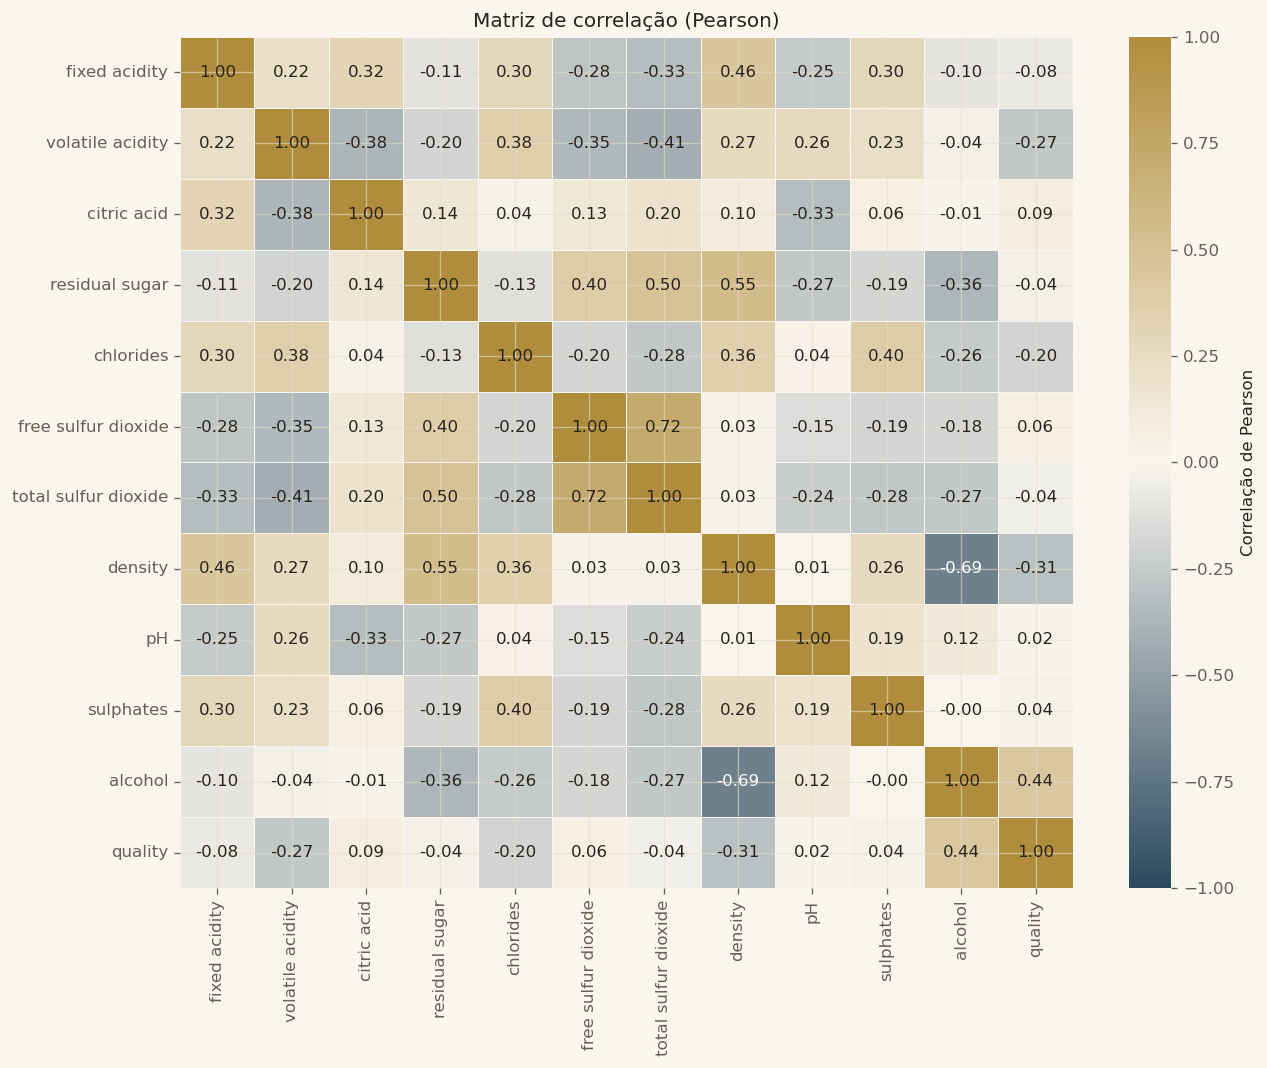

In [14]:
corr = df.drop(columns=['tipo']).corr(numeric_only=True)

# colormap sequencial (creme→azul), reaproveitado mais adiante no scatter alcohol × density
custom_cmap = sns.blend_palette(['#FAF6EF', '#2C4A5E'], as_cmap=True)

# colormap divergente para correlação: petróleo (-1) → bege (0) → dourado (+1) — o zero tem significado aqui
from matplotlib.colors import LinearSegmentedColormap
corr_cmap = LinearSegmentedColormap.from_list('jlp_div', ['#2C4A5E', '#FAF6EF', '#B08D3C'])

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap=corr_cmap, center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='#FAF6EF', ax=ax, cbar_kws={'label': 'Correlação de Pearson'}
)

# ajusta a cor de cada anotação conforme a luminância da célula, para manter contraste nos dois extremos da escala
norm = plt.Normalize(vmin=-1, vmax=1)
for text, value in zip(ax.texts, corr.values.flatten()):
    r, g, b, _ = corr_cmap(norm(value))
    luminancia = 0.299 * r + 0.587 * g + 0.114 * b
    text.set_color('white' if luminancia < 0.5 else '#2A231C')

ax.set_title('Matriz de correlação (Pearson)')
fig.tight_layout()

plt.savefig('../images/heatmap-correlacao.png')
plt.show()

In [15]:
# isola só a coluna de correlação com quality, ordenada da mais positiva para a mais negativa
corr['quality'].sort_values(ascending=False)

quality                 1.000000
alcohol                 0.444319
citric acid             0.085532
free sulfur dioxide     0.055463
sulphates               0.038485
pH                      0.019506
residual sugar         -0.036980
total sulfur dioxide   -0.041385
fixed acidity          -0.076743
chlorides              -0.200666
volatile acidity       -0.265699
density                -0.305858
Name: quality, dtype: float64

**O que levamos daqui:** `alcohol` tem a correlação mais forte com `quality` entre todas as variáveis do dataset: 0,44. Pela régua acima, isso é uma relação moderada e positiva — clara, mas longe de perfeita. Nenhuma variável sozinha "explica" a nota de um vinho.

No lado negativo, `density` (-0,31) e `volatile acidity` (-0,27) se destacam. Uma correlação negativa não é "ruim" — só indica direção oposta: quando a densidade sobe, a nota tende a cair (e vice-versa). Isso tem uma explicação física direta: álcool é menos denso que água, então mais álcool tende a significar menos densidade — a correlação entre `density` e `alcohol` é de -0,69, a mais forte envolvendo `alcohol` no dataset (a correlação mais forte do dataset como um todo é entre os dois indicadores de dióxido de enxofre, `free sulfur dioxide` e `total sulfur dioxide`, com 0,72). Já a acidez volátil está ligada a um defeito sensorial (o gosto de vinagre mencionado na seção 2), o que penaliza a nota diretamente.

Um ponto importante: **correlação não é causalidade**. O fato de o álcool correlacionar com notas mais altas não significa que aumentar artificialmente o teor alcoólico melhora um vinho. É mais provável que ambos sejam consequência de um mesmo processo — uvas mais maduras, fermentação mais completa — que também resulta em vinhos melhor avaliados.

## 8. Relações-chave com a variável-alvo

Com `alcohol`, `volatile acidity`, `citric acid` e `sulphates` identificadas como as features mais relevantes para `quality`, vamos olhar como cada uma se distribui por nota, usando boxplots — já explicados na seção 6.

Depois, cruzamos `alcohol` com `density` — as duas variáveis mais fortemente correlacionadas entre si — num **scatter plot** (gráfico de dispersão): cada ponto representa um vinho, posicionado conforme seu teor alcoólico (eixo x) e densidade (eixo y). A cor de cada ponto indica a nota de qualidade daquele vinho, conforme a legenda ao lado.

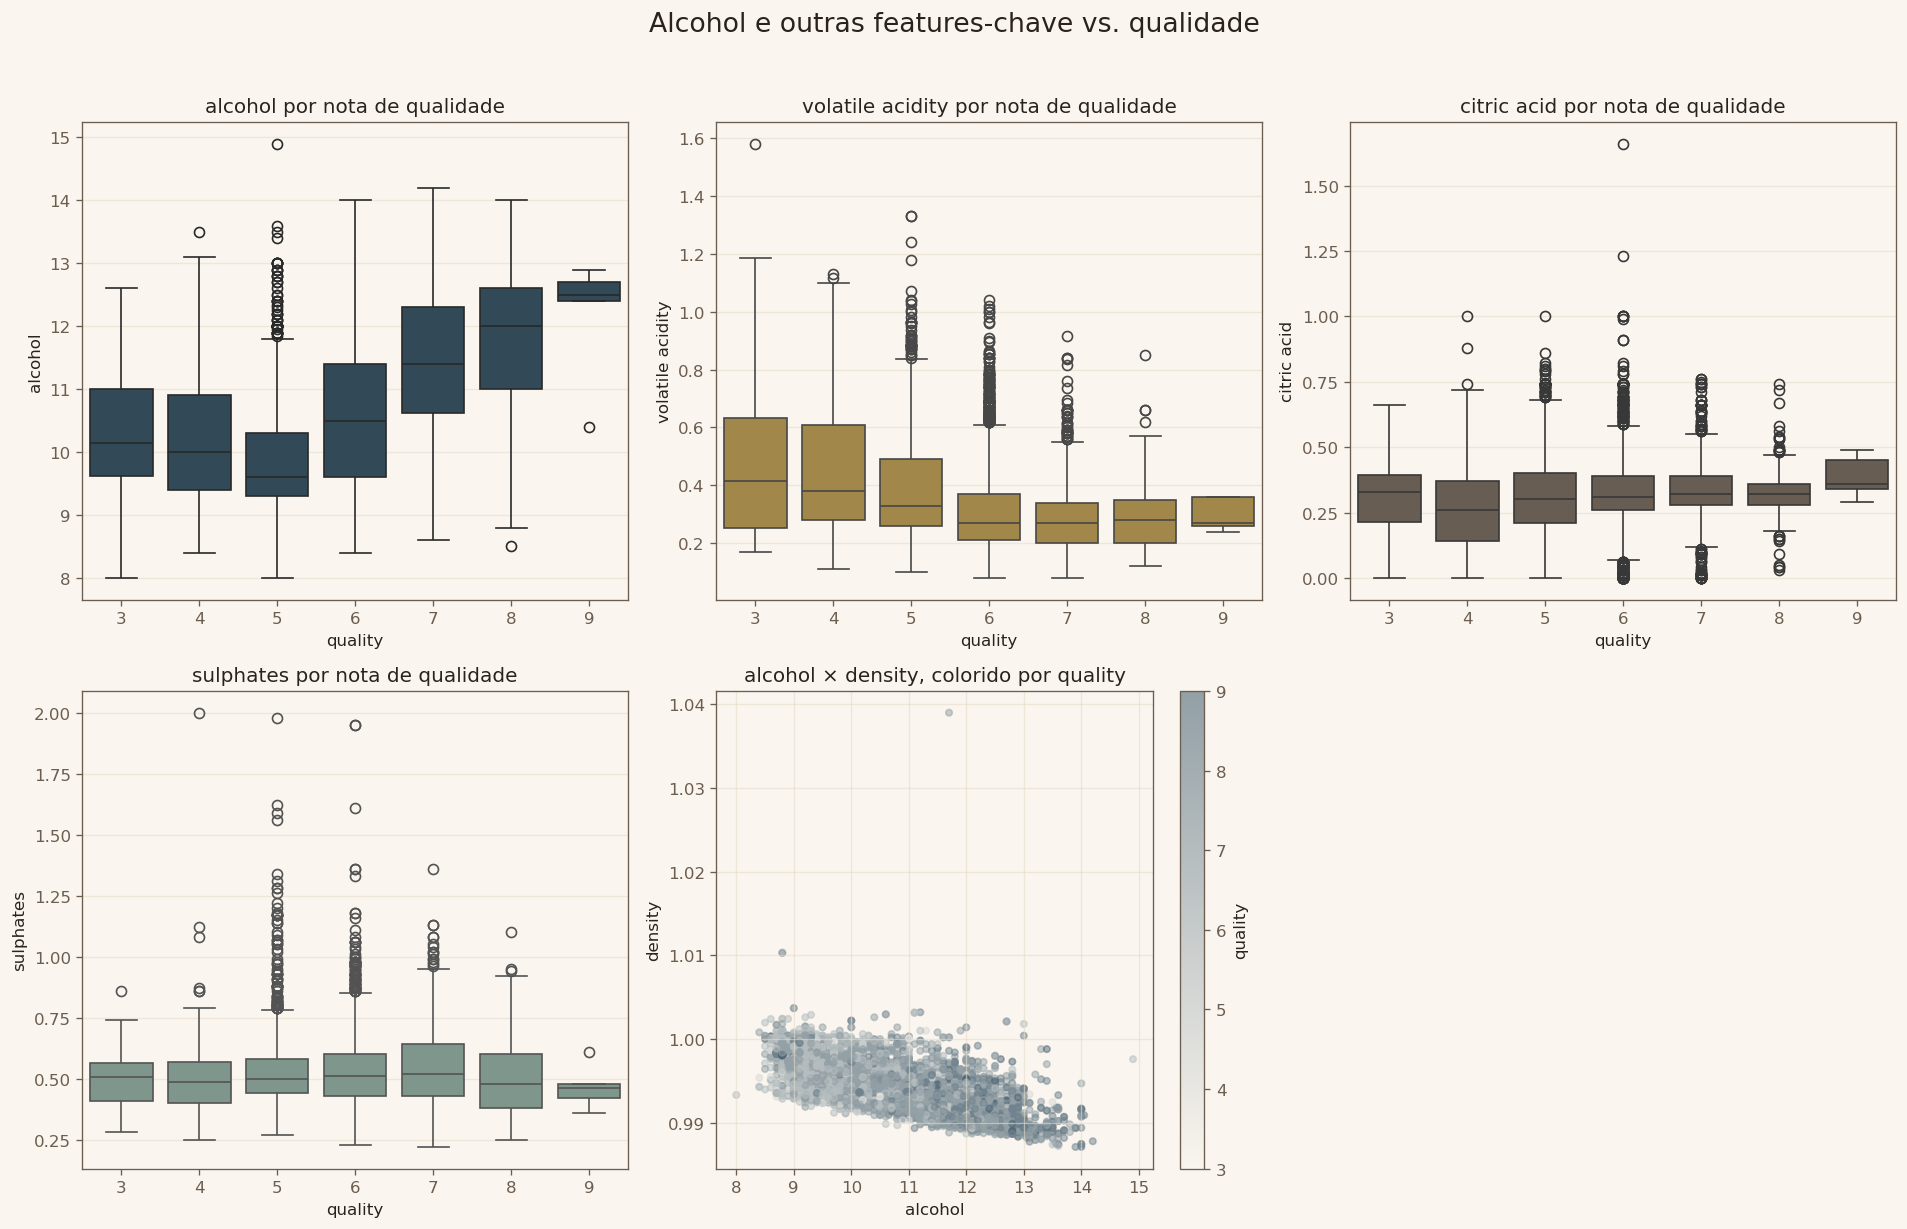

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

key_features = ['alcohol', 'volatile acidity', 'citric acid', 'sulphates']
for i, col in enumerate(key_features):
    sns.boxplot(data=df, x='quality', y=col, ax=axes[i], color=PALETTE[i % len(PALETTE)])
    axes[i].set_title(f'{col} por nota de qualidade')

scatter = axes[4].scatter(
    df['alcohol'], df['density'], c=df['quality'], cmap=custom_cmap, alpha=0.5, s=15
)
axes[4].set_xlabel('alcohol')
axes[4].set_ylabel('density')
axes[4].set_title('alcohol × density, colorido por quality')
fig.colorbar(scatter, ax=axes[4], label='quality')

axes[5].axis('off')

fig.suptitle('Alcohol e outras features-chave vs. qualidade', fontsize=16, y=1.02)
fig.tight_layout()

plt.savefig('../images/alcohol-vs-qualidade.png')
plt.show()

In [17]:
# mediana e média de alcohol por nota — para checar se a subida é mesmo linear em toda a escala
df.groupby('quality')['alcohol'].agg(['median', 'mean', 'count']).round(2)

,median,mean,count
quality,,,
3,10.15,10.22,30
4,10.00,10.18,216
5,9.60,9.84,2138
6,10.50,10.59,2836
7,11.40,11.39,1079
8,12.00,11.68,193
9,12.50,12.18,5


In [18]:
# agrupa por nota alta (>=7) vs. o restante, para comparar o "perfil médio" dos dois grupos
df.groupby(df['quality'] >= 7)[['alcohol', 'volatile acidity', 'density', 'sulphates']].mean().rename(
    index={False: 'nota < 7', True: 'nota >= 7'}
)

,alcohol,volatile acidity,density,sulphates
quality,,,,
nota < 7,10.261462,0.352019,0.995105,0.528768
nota >= 7,11.433359,0.289170,0.993027,0.541488


**O que levamos daqui:** à primeira vista, a correlação de Pearson entre `alcohol` e `quality` (0,44, a mais forte com a nota) sugere uma leitura simples: quanto mais álcool, melhor a nota. O boxplot de `alcohol` por nota conta uma história mais rica.

A tabela acima mostra a mediana de `alcohol` em cada nota: ela cai de 10,15% (nota 3) para 10,00% (nota 4) e atinge o mínimo em 9,60% (nota 5) — e só a partir daí sobe de forma consistente: 10,50% (nota 6), 11,40% (nota 7), 12,00% (nota 8) e 12,50% (nota 9). Não é uma reta ascendente; é uma curva em U, com ponto de virada na nota 5.

Por que a correlação de Pearson não capturou esse padrão? Porque ela mede especificamente relação **linear** — o quanto os pontos se aproximam de uma reta. Uma relação que cai e depois sobe fica parcialmente invisível para um número que só enxerga retas: o Pearson resume a tendência geral (mais nota, mais álcool, em média, do meio da escala em diante), mas esconde o que acontece nas notas mais baixas.

A lição vale além deste dataset: **o número resume, o gráfico revela**. É por isso que a análise exploratória vem antes de qualquer modelo — quem olha só a matriz de correlação aceita uma versão simplificada, e neste caso imprecisa, da história.

O restante do padrão se mantém: a mediana de `volatile acidity` cai de forma consistente conforme a nota sobe. Comparando vinhos com nota 7 ou mais contra o restante: a acidez volátil média cai de 0,352 para 0,289, e a densidade média cai de 0,9951 para 0,9930. `citric acid` e `sulphates` mostram uma tendência mais fraca, mas ainda perceptível.

No scatter, os pontos de nota mais alta aparecem mais concentrados na região de baixa densidade e alto teor alcoólico — um padrão consistente com a subida observada no boxplot a partir da nota 5.

Juntando tudo: vinhos "melhores" (nota ≥ 7) têm um perfil químico distinguível dos demais, embora a relação entre álcool e nota não seja simplesmente linear em toda a escala. Não é uma separação perfeita — há sobreposição entre os grupos —, mas há sinal real o suficiente para justificar uma tentativa de modelagem preditiva.

## 9. Tinto vs. branco: perfis diferentes?

Até aqui tratamos o dataset como um bloco único. Mas tinto e branco são produzidos de formas diferentes — o branco costuma fermentar sem a casca da uva, por exemplo —, e isso deveria aparecer na química. Comparamos abaixo as distribuições de quatro features onde essa diferença mais aparece, usando um **violin plot**.

O nome vem do formato: o gráfico lembra um violino apoiado de lado. A largura em cada altura mostra quantos vinhos existem naquela faixa de valor — onde a forma fica mais "gorda", há muitos vinhos concentrados; onde fica fina, poucos. É, na prática, um histograma espelhado e deitado, o que facilita comparar a forma da distribuição entre dois grupos lado a lado (aqui, tinto e branco).

/tmp/ipykernel_305836/658383379.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_305836/658383379.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_305836/658383379.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_305836/658383379.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


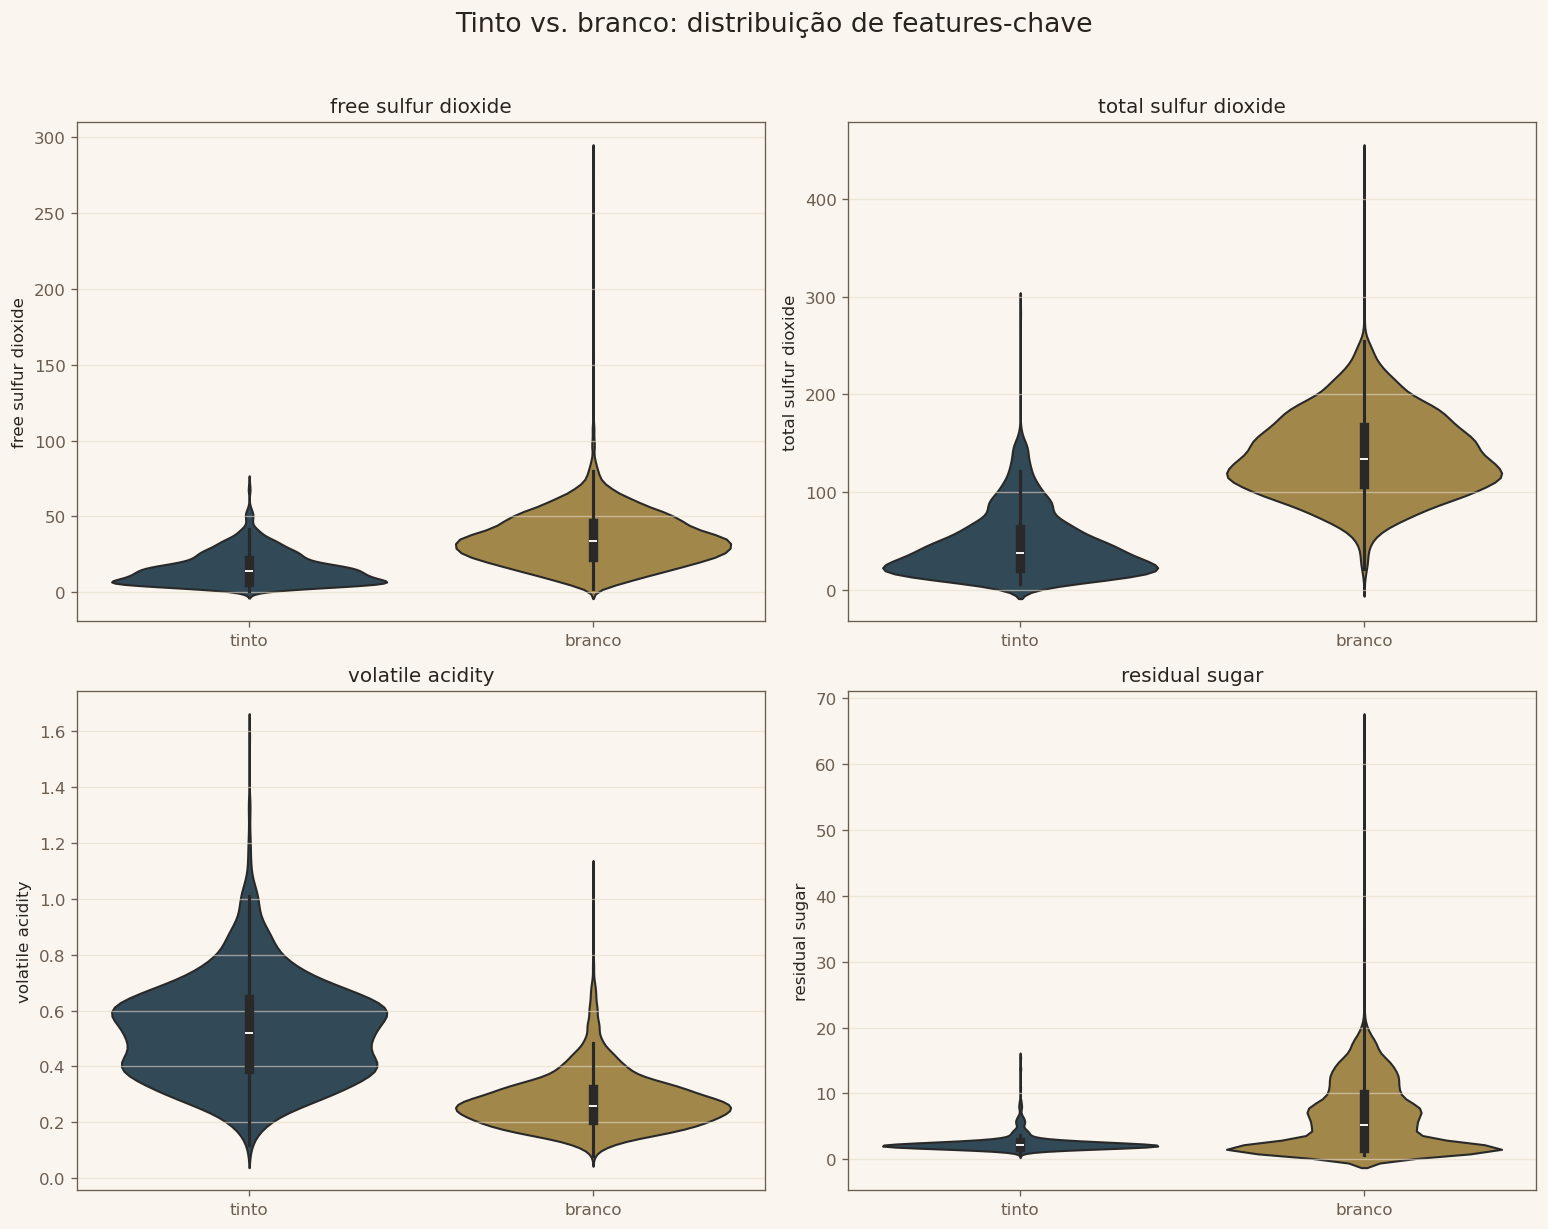

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

compare_features = ['free sulfur dioxide', 'total sulfur dioxide', 'volatile acidity', 'residual sugar']
for i, col in enumerate(compare_features):
    sns.violinplot(
        data=df, x='tipo', y=col, ax=axes[i],
        palette={'tinto': PALETTE[0], 'branco': PALETTE[1]}
    )
    axes[i].set_title(col)
    axes[i].set_xlabel('')

fig.suptitle('Tinto vs. branco: distribuição de features-chave', fontsize=16, y=1.02)
fig.tight_layout()

plt.savefig('../images/tinto-vs-branco.png')
plt.show()

In [20]:
# compara a média de cada feature entre os dois tipos de vinho
df.groupby('tipo')[compare_features].mean()

,free sulfur dioxide,total sulfur dioxide,volatile acidity,residual sugar
tipo,,,,
branco,35.308085,138.360657,0.278241,6.391415
tinto,15.874922,46.467792,0.527821,2.538806


**O que levamos daqui:** os perfis são claramente diferentes. O vinho branco tem, em média, mais que o dobro de SO2 livre (35,3 contra 15,9) e quase três vezes mais SO2 total (138,4 contra 46,5) do que o tinto — o branco costuma precisar de mais sulfitos para se proteger da oxidação, já que não conta com os taninos da casca da uva, que cumprem parte desse papel no tinto. A acidez volátil do tinto é quase o dobro da do branco (0,528 contra 0,278), e o açúcar residual do branco é cerca de 2,5 vezes maior (6,39 contra 2,54).

Essas diferenças sistemáticas sugerem que tratar tinto e branco como um único dataset homogêneo pode mascarar padrões. Um modelo preditivo provavelmente se beneficia de usar `tipo` como feature — ou até de treinar dois modelos separados, um para cada tipo de vinho.

## 10. Resumo de insights e próximos passos

### Principais insights

1. **Dataset limpo, mas desbalanceado.** Não há valores nulos, mas a variável-alvo `quality` está fortemente concentrada nas notas 5, 6 e 7 (mais de 93% dos registros) — notas extremas (3, 4, 8, 9) são raras. Isso é um desbalanceamento de classes: um modelo pode parecer bom só "chutando" as notas do meio, sem realmente aprender o que diferencia um vinho excelente de um mediano.
2. **Álcool é o preditor mais forte de qualidade — mas a relação não é linear.** Correlação de Pearson de 0,44 com `quality` (numa escala de -1 a 1), a mais forte com a nota entre todas as variáveis do dataset — mas o Pearson só enxerga relação linear, e a mediana de `alcohol` na verdade cai até a nota 5 e só depois sobe de forma consistente (curva em U, seção 8). Vinhos com nota ≥ 7 têm teor alcoólico médio de 11,43%, contra 10,26% dos demais.
3. **Densidade e acidez volátil puxam a nota para baixo.** Correlações de -0,31 e -0,27 com `quality` — negativas, ou seja, quando essas variáveis sobem, a nota tende a cair. Densidade mais baixa está fisicamente ligada a mais álcool (correlação de -0,69 entre as duas, a mais forte envolvendo `alcohol` no dataset), o que ajuda a explicar o padrão.
4. **Outlier não é sinônimo de erro.** Valores extremos em `residual sugar`, `chlorides` e nas variáveis de dióxido de enxofre provavelmente refletem estilos legítimos de vinho (vinhos doces, escolhas de conservação do produtor) — remover automaticamente esses pontos descartaria informação real, sem justificativa técnica.
5. **Tinto e branco têm perfis químicos distintos.** O branco tem muito mais SO2 (livre e total) e açúcar residual; o tinto tem mais acidez volátil. Essa diferença sistemática é forte o suficiente para justificar usar `tipo` como feature em um modelo.
6. **As features estão em escalas bem diferentes.** `chlorides` fica na casa dos centésimos (média de 0,056) enquanto `total sulfur dioxide` fica na casa das centenas (média de 115,7). Para EDA isso não atrapalha, mas modelos sensíveis a escala (regressão logística, KNN, redes neurais) tendem a dar peso desproporcional às variáveis com números maiores, a menos que os dados sejam normalizados antes do treino.

### Próximos passos

- **Feature engineering:** avaliar se faz sentido transformar `quality` em uma variável binária — "bom" (≥ 7) vs. "regular" (< 7) — para simplificar o problema diante do desbalanceamento das notas extremas; ou agrupar em faixas (baixo/médio/alto).
- **Normalização:** padronizar as features antes de qualquer modelo sensível a escala.
- **Tratamento do desbalanceamento:** técnicas como pesos por classe (*class weights*), superamostragem (*oversampling*, ex. SMOTE) ou reamostragem estratificada, dependendo do modelo escolhido.
- **Modelagem:** com o sinal identificado nas seções 7 e 8 (especialmente `alcohol`, `volatile acidity`, `density`), um classificador supervisionado (Random Forest, Gradient Boosting, regressão logística) é o próximo passo natural.